In [2]:
import numpy as np 
import time
import tracemalloc

def inject_svd_lora(w, p, s=0.1):
    tracemalloc.start()
    start = time.time()
    u, sv, vt = np.linalg.svd(w, full_matrices=False)
    sig = np.diag(sv)
    for i in range(len(p)):
        sig[i, i] += s * p[i]
    mw = np.dot(u, np.dot(sig, vt))
    end = time.time()
    elapsed = end - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"Time taken to run the function: {elapsed:.6f} seconds")
    err = np.linalg.norm(w - mw) / np.linalg.norm(w)
    return mw, err, peak / 10**6, elapsed

w = np.random.randn(5, 5)
p = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
mw, err, peak, elapsed = inject_svd_lora(w, p)
print("Original Weight Matrix:\n", w)
print("\nModified Weight Matrix with Injected Preferences:\n", mw)
print(f"Peak memory usage: {peak:.2f} MB")
print(f"Reconstruction Error: {err:.6f}")


Time taken to run the function: 0.001049 seconds
Original Weight Matrix:
 [[ 0.59234452 -2.56391098  0.75847671  1.77737609  0.59928137]
 [ 1.67563693  0.91406693  0.12094223 -0.52968519  0.75494616]
 [ 0.79931715 -0.21928058 -2.73016706 -1.09466387 -0.36601758]
 [ 0.00752419  1.14895248 -0.30717242 -0.0251977  -2.22688591]
 [ 0.18999135  1.74789637 -1.42552056  0.04252611 -0.73499956]]

Modified Weight Matrix with Injected Preferences:
 [[ 0.60870269 -2.62486746  0.77041445  1.8176924   0.61144347]
 [ 1.71843013  0.93603682  0.12373028 -0.54279771  0.77686296]
 [ 0.82235015 -0.23270594 -2.80203384 -1.12041918 -0.37021121]
 [ 0.00445941  1.17652503 -0.31049125 -0.02163733 -2.2819207 ]
 [ 0.19504909  1.78611251 -1.45627633  0.04324797 -0.75276832]]
Peak memory usage: 0.01 MB
Reconstruction Error: 0.024371


Time taken to run the function: 0.000104 seconds
Size: 10x10 - Time: 0.000104s, Memory: 0.01MB, Error: 0.017808
Time taken to run the function: 0.000393 seconds
Size: 50x50 - Time: 0.000393s, Memory: 0.10MB, Error: 0.007903
Time taken to run the function: 0.001060 seconds
Size: 100x100 - Time: 0.001060s, Memory: 0.40MB, Error: 0.006167
Time taken to run the function: 0.003634 seconds
Size: 200x200 - Time: 0.003634s, Memory: 1.60MB, Error: 0.004172
Time taken to run the function: 0.008639 seconds
Size: 300x300 - Time: 0.008639s, Memory: 3.60MB, Error: 0.003224
Time taken to run the function: 0.014490 seconds
Size: 400x400 - Time: 0.014490s, Memory: 6.40MB, Error: 0.002869
Time taken to run the function: 0.024568 seconds
Size: 500x500 - Time: 0.024568s, Memory: 10.00MB, Error: 0.002593


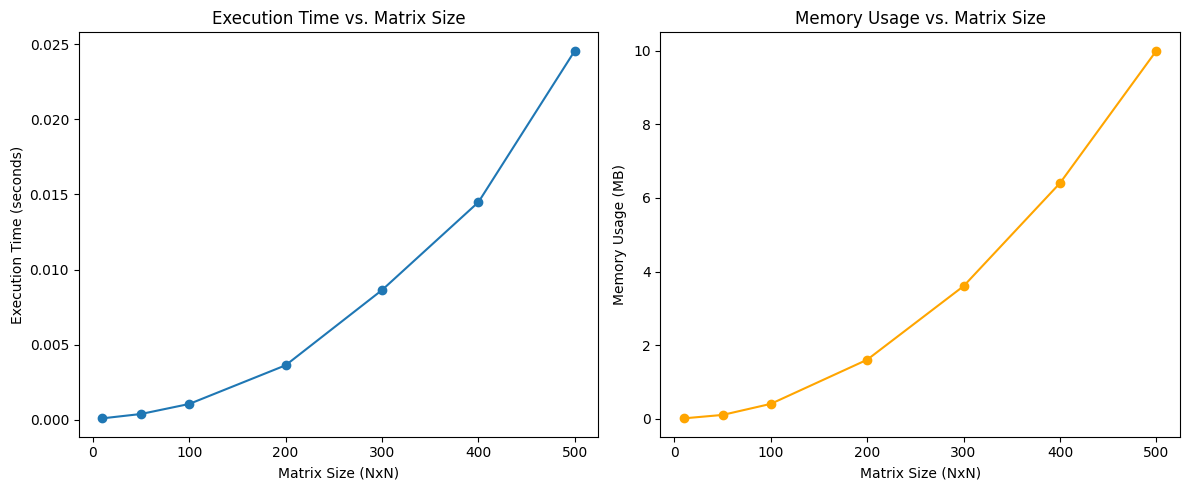

In [3]:
import matplotlib.pyplot as plt
ms = [10, 50, 100, 200, 300, 400, 500]
times = []
mems = []
errs = []
for sz in ms:
    w = np.random.randn(sz, sz)
    p = np.random.rand(sz)
    mw, err, peak, elapsed = inject_svd_lora(w, p)
    times.append(elapsed)
    mems.append(peak)
    errs.append(err)
    print(f"Size: {sz}x{sz} - Time: {elapsed:.6f}s, Memory: {peak:.2f}MB, Error: {err:.6f}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ms, times, marker='o')
plt.xlabel('Matrix Size (NxN)')
plt.ylabel('Execution Time (seconds)')
plt.title('Execution Time vs. Matrix Size')
plt.subplot(1, 2, 2)
plt.plot(ms, mems, marker='o', color='orange')
plt.xlabel('Matrix Size (NxN)')
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage vs. Matrix Size')

plt.tight_layout()
plt.show()


In [4]:
import numpy as np
import time
def block_diag_inject(w, p, s=0.1):
    start = time.time()
    nb = len(p)
    bs = w.shape[0] // nb
    mw_block = np.zeros_like(w)
    for i in range(nb):
        si = i * bs
        ei = si + bs
        blk = w[si:ei, si:ei]
        new_blk = blk + s * p[i] * np.eye(bs)
        mw_block[si:ei, si:ei] = new_blk
    end = time.time()
    elapsed = end - start
    print(f"Time taken to run the function: {elapsed:.6f} seconds")
    return mw_block
w = np.random.randn(5, 5)
p = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
mw_block = block_diag_inject(w, p)
print("Original Weight Matrix:\n", w)
print("\nModified Weight Matrix with Injected Preferences (Block Diagonal):\n", mw_block)


Time taken to run the function: 0.000061 seconds
Original Weight Matrix:
 [[-0.29109902 -0.83921873 -0.88701074 -0.7504859  -0.82048935]
 [ 0.96200317  1.3415724   1.8325915   0.21294968 -2.22402851]
 [-0.32206955 -0.25419491  1.46964808  1.1711978   0.05798349]
 [-2.71103537 -0.9230819   0.32375028 -0.78221768 -0.54742396]
 [ 0.02527543 -1.07512736 -0.62700082  1.72083242  1.62634815]]

Modified Weight Matrix with Injected Preferences (Block Diagonal):
 [[-0.19109902  0.          0.          0.          0.        ]
 [ 0.          1.4215724   0.          0.          0.        ]
 [ 0.          0.          1.52964808  0.          0.        ]
 [ 0.          0.          0.         -0.74221768  0.        ]
 [ 0.          0.          0.          0.          1.64634815]]


Time taken to run the function: 0.000134 seconds
Peak memory usage: 0.01 MB
Original Weight Matrix:
 [[ 0.12257161  0.30955219  0.02882773 -0.30429536  1.70286953]
 [ 0.39313319 -0.11169395 -1.24576746  0.07827986  0.25903769]
 [-1.08106878 -1.24791523 -2.14541155 -2.1940415  -0.29506489]
 [ 1.36790545 -1.13174954  0.203495   -0.8595919  -0.76856068]
 [-1.06691205 -0.46775268  0.86402256 -0.47816063 -1.46137994]]

Modified Weight Matrix with Injected Preferences (Block Diagonal):
 [[ 0.22257161  0.          0.          0.          0.        ]
 [ 0.         -0.03169395  0.          0.          0.        ]
 [ 0.          0.         -2.08541155  0.          0.        ]
 [ 0.          0.          0.         -0.8195919   0.        ]
 [ 0.          0.          0.          0.         -1.44137994]]
Time taken to run the function: 0.000105 seconds
Peak memory usage: 0.01 MB
Size: 10x10 - Time: 0.000105s, Memory: 0.01MB
Time taken to run the function: 0.000156 seconds
Peak memory usage: 0.03 MB


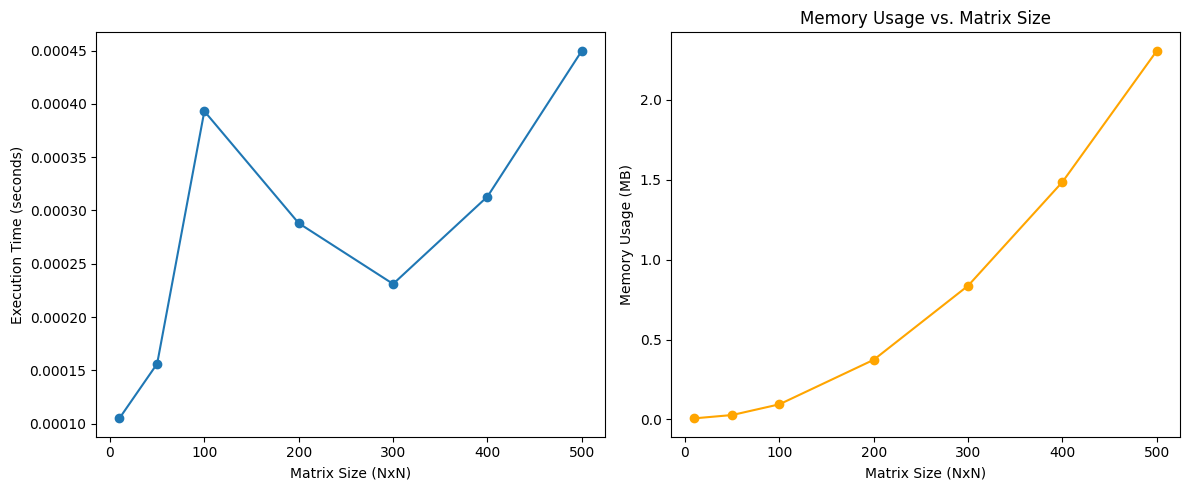

In [5]:
import numpy as np
import time
import tracemalloc
import matplotlib.pyplot as plt

def block_diag_inject(w, p, s=0.1):
    tracemalloc.start()
    start = time.time()
    nb = len(p)
    bs = w.shape[0] // nb
    mw_block = np.zeros_like(w)
    for i in range(nb):
        si = i * bs
        ei = si + bs
        blk = w[si:ei, si:ei]
        new_blk = blk + s * p[i] * np.eye(bs)
        mw_block[si:ei, si:ei] = new_blk
    end = time.time()
    elapsed = end - start
    _, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"Time taken to run the function: {elapsed:.6f} seconds")
    print(f"Peak memory usage: {peak / 10**6:.2f} MB")
    return mw_block, elapsed, peak / 10**6
w = np.random.randn(5, 5)
p = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
mw_block, _, _ = block_diag_inject(w, p)
print("Original Weight Matrix:\n", w)
print("\nModified Weight Matrix with Injected Preferences (Block Diagonal):\n", mw_block)
ms = [10, 50, 100, 200, 300, 400, 500]
times = []
mems = []
for sz in ms:
    w = np.random.randn(sz, sz)
    p = np.random.rand(sz // (sz // len(p)))
    _, elapsed, peak = block_diag_inject(w, p)
    times.append(elapsed)
    mems.append(peak)
    print(f"Size: {sz}x{sz} - Time: {elapsed:.6f}s, Memory: {peak:.2f}MB")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(ms, times, marker='o')
plt.xlabel('Matrix Size (NxN)')
plt.ylabel('Execution Time (seconds)')
plt.subplot(1, 2, 2)
plt.plot(ms, mems, marker='o', color='orange')
plt.xlabel('Matrix Size (NxN)')
plt.ylabel('Memory Usage (MB)')
plt.title('Memory Usage vs. Matrix Size')
plt.tight_layout()
plt.show()
